In [70]:
import os, json, pickle, math
from copy import deepcopy
from typing import List, Dict, Any
from collections import namedtuple, defaultdict

import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import (
    Polygon, MultiPolygon, LineString, MultiLineString, Point, GeometryCollection, shape
)
from shapely.geometry import mapping as shp_mapping
from shapely.ops import unary_union
from shapely.strtree import STRtree

import resplan_utils as R  # your helper lib

# ---- paths ----
DATA_PKL     = "ResPlan.pkl"
OUT_JSON_DIR = "resplan_json"
OUT_PLOT_DIR = "resplan_plot"
os.makedirs(OUT_JSON_DIR, exist_ok=True)
os.makedirs(OUT_PLOT_DIR,  exist_ok=True)

# ---- categories ----
ROOM_KEYS   = ["bedroom","bathroom","kitchen","living","balcony","storage","stair","veranda","parking"]
STRUCT_KEYS = ["interior_wall","exterior_wall","door","window","front_door"]
GEOM_LAYERS = ["inner","garden","land","pool"]
META_KEYS   = ["id","unitType","area","net_area","wall_depth"]

# ---- colors (viz) ----
ROOM_COLORS = {
    "living":   "#d9d9d9",
    "bedroom":  "#66c2a5",
    "bathroom": "#fc8d62",
    "kitchen":  "#8da0cb",
    "balcony":  "#b3b3b3",
    "storage":  "#cccccc",
    "stair":    "#aaaaaa",
    "veranda":  "#bbbbbb",
    "parking":  "#dddddd",
}
STRUCT_COLORS = {
    "interior_wall": "#445DFF",
    "exterior_wall": "#FFD344",
    "door":          "#e78ac3",
    "window":        "#a6d854",
    "front_door":    "#a63603",
}

# ---- tolerances (m) ----
EPS_LEN = 0.02
EPS_AREA = 0.01
WALL_BUFFER = 0.02
OPENING_BUFFER = 0.005

# ---- small utils ----
def _f(x, nd=6):
    try: return round(float(x), nd)
    except: return x

GeoRec = namedtuple("GeoRec", "id cls subtype level geom raw")

In [71]:
def geojsonify(geom):
    if geom is None:
        return {"type": "GeometryCollection", "geometries": []}
    if isinstance(geom, (Polygon, MultiPolygon, LineString, MultiLineString, Point)):
        return {"type": "GeometryCollection", "geometries": []} if geom.is_empty else shp_mapping(geom)
    parts = [g for g in R.get_geometries(geom)]
    if not parts:
        return {"type": "GeometryCollection", "geometries": []}
    if all(isinstance(g, Polygon) for g in parts):
        return {"type": "MultiPolygon", "coordinates": [shp_mapping(g)["coordinates"] for g in parts]}
    return {"type": "GeometryCollection", "geometries": [shp_mapping(g) for g in parts]}

def bbox_of_geom(geom):
    if geom is None or getattr(geom, "is_empty", True): return [None, None, None, None]
    x1, y1, x2, y2 = geom.bounds
    return [float(x1), float(y1), float(x2), float(y2)]

def assign_ids(n, prefix):
    return [f"{prefix}-{i:04d}" for i in range(1, n+1)]

def _geom(obj):
    if obj is None: return None
    g = obj.get("geom") if isinstance(obj, dict) else None
    if isinstance(g, dict) and "type" in g: return shape(g)
    return None

def _id(obj, fallback_prefix):
    if isinstance(obj, dict) and "id" in obj: return str(obj["id"])
    return f"{fallback_prefix}-{abs(hash(str(obj)))%10**8:08d}"

def _level(obj):
    return obj.get("level") or obj.get("storey") or obj.get("props", {}).get("level")

def find_instances(plan):
    out = {"rooms": [], "walls": [], "openings": []}
    if "instances" not in plan: return out

    # rooms
    if "room" in plan["instances"]:
        room_data = plan["instances"]["room"]
        for room_type, room_list in room_data.items():
            for room in room_list: out["rooms"].append(room)

    # structural
    if "structural" in plan["instances"]:
        st = plan["instances"]["structural"]
        for wall_type in ["interior_wall","exterior_wall"]:
            for wall in st.get(wall_type, []):
                w = deepcopy(wall); w.setdefault("subtype", "exterior" if "exterior" in wall_type else "interior")
                out["walls"].append(w)
        for opening_type in ["door","window","front_door"]:
            for opening in st.get(opening_type, []):
                o = deepcopy(opening); o.setdefault("subtype", opening_type)
                out["openings"].append(o)
    return out

In [ ]:
ROOM_PREFIX = {
    "bathroom": "BTH",
    "balcony":"BAL",
    "bedroom":"BED",
    "living":"LIV",
    "kitchen":"KIT",
    "corridor":"COR",
    "hall":"HAL",
    "storage":"STRG",
    "toilet":"WC",
    "dining":"DIN",
    "study":"STD",
    "laundry":"LDY",
    "stair":"STR",  
    "veranda":"VER",
    "parking":"PRK",
}


def _update_rel_table(tbl, slots, remap):
    if not isinstance(tbl, list): return
    for e in tbl:
        for slot in slots:
            if slot == "rooms" and isinstance(e.get(slot), list):
                e[slot] = [remap.get(x, x) for x in e[slot]]
            else:
                v = e.get(slot)
                if v in remap: e[slot] = remap[v]

def _apply_room_id_remap(plan, remap):
    rel = plan.get("relations")
    if isinstance(rel, dict):
        _update_rel_table(rel.get("bounded_by"), ["room"], remap)
        _update_rel_table(rel.get("adjacent_to"), ["a","b"], remap)
        _update_rel_table(rel.get("connected_via_door"), ["rooms"], remap)
        _update_rel_table(rel.get("window_connects"), ["from","to"], remap)
        _update_rel_table(rel.get("contains"), ["container"], remap)
    grel = plan.get("graph", {}).get("relations")
    if isinstance(grel, dict):
        _update_rel_table(grel.get("bounded_by"), ["room"], remap)
        _update_rel_table(grel.get("adjacent_to"), ["a","b"], remap)
        _update_rel_table(grel.get("connected_via_door"), ["rooms"], remap)
        _update_rel_table(grel.get("window_connects"), ["from","to"], remap)
        _update_rel_table(grel.get("contains"), ["container"], remap)

def relabel_rooms_with_subtype_prefixes_inplace(plan):
    inst = plan.get("instances", {})
    remap = {}

    room_dict = inst.get("room")
    if isinstance(room_dict, dict):
        for subtype, arr in room_dict.items():
            pref = ROOM_PREFIX.get(subtype.lower(), "RM")
            new_ids = assign_ids(len(arr), pref)
            for i, rec in enumerate(arr):
                old, new = rec.get("id"), new_ids[i]
                if old and old != new: remap[old] = new; rec["id"] = new
    elif isinstance(inst.get("rooms"), list):
        by_sub = {}
        for rec in inst["rooms"]:
            st = (rec.get("subtype") or "unknown").lower()
            by_sub.setdefault(st, []).append(rec)
        for subtype, arr in by_sub.items():
            pref = ROOM_PREFIX.get(subtype, "RM")
            new_ids = assign_ids(len(arr), pref)
            for i, rec in enumerate(arr):
                old, new = rec.get("id"), new_ids[i]
                if old and old != new: remap[old] = new; rec["id"] = new
    else:
        for key in ("rooms","room"):
            if isinstance(plan.get(key), list):
                by_sub = {}
                for rec in plan[key]:
                    st = (rec.get("subtype") or "unknown").lower()
                    by_sub.setdefault(st, []).append(rec)
                for subtype, arr in by_sub.items():
                    pref = ROOM_PREFIX.get(subtype, "RM")
                    new_ids = assign_ids(len(arr), pref)
                    for i, rec in enumerate(arr):
                        old, new = rec.get("id"), new_ids[i]
                        if old and old != new: remap[old] = new; rec["id"] = new

    if remap: _apply_room_id_remap(plan, remap)
    return remap

In [135]:
def _walls_as_polygons(plan, fallback_frac=0.01):
    W = R.get_plan_width(plan) or 1.0
    bufw = fallback_frac * W
    polys = []
    for g in R.get_geometries(plan.get("wall")):
        if isinstance(g, (Polygon, MultiPolygon)):
            polys += [g] if isinstance(g, Polygon) else list(g.geoms)
        elif isinstance(g, (LineString, MultiLineString)):
            polys.append(g.buffer(bufw, join_style=2, cap_style=2))
    return unary_union(polys).buffer(0)

def _instances_from_geom(category: str, geom, min_area: float = 2.0) -> list:
    """
    Convert geometry to instances with proper validation.
    Only creates instances for significant, valid geometries.
    """
    if geom is None or geom.is_empty:
        return []
    
    # Extract polygons
    if isinstance(geom, MultiPolygon):
        polys = list(geom.geoms)
    elif isinstance(geom, Polygon):
        polys = [geom]
    else:
        print(f"WARNING: Unexpected geometry type for {category}: {geom.geom_type}")
        return []
    
    # Filter valid polygons BEFORE creating instances
    valid_polys = []
    for p in polys:
        if not isinstance(p, Polygon):
            continue
            
        area = p.area
        
        # Skip tiny artifacts
        if area < min_area:
            print(f"SKIPPED: {category} fragment with area {area:.2f}m²")
            continue
        
        # Skip invalid geometry
        if not p.is_valid:
            print(f"SKIPPED: Invalid {category} geometry")
            continue
        
        # Skip if too elongated (likely a sliver artifact)
        try:
            bounds = p.bounds
            width = bounds[2] - bounds[0]
            height = bounds[3] - bounds[1]
            aspect_ratio = max(width, height) / (min(width, height) + 1e-6)
            if aspect_ratio > 50:  # Very thin sliver
                print(f"SKIPPED: {category} sliver (aspect ratio {aspect_ratio:.1f})")
                continue
        except:
            pass
        
        valid_polys.append(p)
    
    if not valid_polys:
        return []
    
    # Now create instances only for valid geometries
    ids = assign_ids(len(valid_polys), category[:2].upper())
    out = []
    for _id, p in zip(ids, valid_polys):
        c = p.centroid
        out.append({
            "id": _id,
            "type": category,
            "geom": geojsonify(p),
            "props": {
                "area": float(p.area),
                "centroid": (float(c.x), float(c.y)),
                "bbox": bbox_of_geom(p)
            }
        })
    
    return out

def split_walls(plan: Dict[str, Any],
                band_factor: float = 1,
                band_min_frac: float = 0.02,
                fallback_frac: float = 0.01) -> Dict[str, list]:
    p = R.normalize_keys(plan.copy())
    inner = p["inner"]
    if inner.geom_type == "MultiPolygon": inner = max(inner.geoms, key=lambda g: g.area)
    W = R.get_plan_width(p) or 1.0
    t = float(p.get("wall_width", 4) or 4)
    band_hw = max(band_factor * t, band_min_frac * W)

    walls_poly    = _walls_as_polygons(p, fallback_frac=fallback_frac)
    boundary_band = inner.boundary.buffer(band_hw, join_style=2, cap_style=2)

    exterior_wall = walls_poly.intersection(boundary_band).buffer(0)
    interior_wall = walls_poly.difference(boundary_band).buffer(0)

    return {
        "interior_wall": _instances_from_geom("interior_wall", interior_wall),
        "exterior_wall": _instances_from_geom("exterior_wall", exterior_wall),
        "door":          _instances_from_geom("door",          p.get("door")),
        "window":        _instances_from_geom("window",        p.get("window")),
        "front_door":    _instances_from_geom("front_door",    p.get("front_door")),
    }

from shapely.ops import unary_union

def extract_room_instances(plan: Dict[str, Any]) -> Dict[str, list]:
    """
    Extract rooms with automatic merging for single-instance types.
    """
    # Room types that should only have one instance per floor plan
    SINGLE_INSTANCE_ROOMS = {"living", "kitchen"}
    
    out = {k: [] for k in ROOM_KEYS}
    
    for rk in ROOM_KEYS:
        geom = plan.get(rk)
        if geom is None:
            continue
        
        # Extract all geometry fragments
        geoms = []
        if hasattr(geom, "geoms"):
            geoms = list(geom.geoms)
        elif hasattr(geom, "__iter__"):
            for g in geom:
                if hasattr(g, "geoms"):
                    geoms.extend(list(g.geoms))
                else:
                    geoms.append(g)
        else:
            geoms = [geom]
        
        # Remove empty geometries
        geoms = [g for g in geoms if not getattr(g, "is_empty", True)]
        
        if not geoms:
            continue
        
        # CRITICAL: Merge fragments for single-instance room types
        if rk in SINGLE_INSTANCE_ROOMS and len(geoms) > 1:
            print(f"Merging {len(geoms)} fragments for {rk}")
            merged = unary_union(geoms)
            
            # After merge, take only the largest component if still fragmented
            if merged.geom_type == "MultiPolygon":
                # Keep only significant pieces (area > 2.0 m²)
                significant = [g for g in merged.geoms if g.area >= 2.0]
                if len(significant) == 1:
                    geoms = significant
                else:
                    # Keep largest component only
                    geoms = [max(merged.geoms, key=lambda g: g.area)]
                    print(f"  → Kept largest component: {geoms[0].area:.1f}m²")
            elif merged.geom_type == "Polygon":
                geoms = [merged]
            else:
                print(f"  → Unexpected merged type: {merged.geom_type}")
        
        # Generate IDs for final geometries
        ids = assign_ids(len(geoms), rk[:2].upper())
        
        for _id, g in zip(ids, geoms):
            c = g.centroid
            centroid = (float(c.x), float(c.y)) if c is not None and not g.is_empty else (None, None)
            out[rk].append({
                "id": _id,
                "type": rk,
                "geom": geojsonify(g),
                "props": {
                    "area": float(getattr(g, "area", 0.0)),
                    "centroid": centroid,
                    "bbox": bbox_of_geom(g)
                }
            })
    
    return out

def extract_metadata(plan, plan_idx: int, json_relpath: str, plot_relpath: str,
                     dataset_name: str = "ResPlan", source_file: str = DATA_PKL,
                     split: str | None = None) -> dict:
    meta = {}
    for k in META_KEYS:
        if k in plan: meta[k] = plan[k]
    if "id" in meta and "plan_id" not in meta: meta["plan_id"] = meta["id"]
    meta.update({"dataset": dataset_name, "plan_idx": int(plan_idx),
                 "plan_label": f"Plan #{plan_idx}", "units": "m"})
    if split is not None: meta["split"] = split
    meta["source"]    = {"file": source_file}
    meta["artifacts"] = {"json_path": json_relpath, "plot_path": plot_relpath}
    return meta

def extract_layers(plan):
    return {k: geojsonify(plan.get(k)) for k in GEOM_LAYERS}

In [136]:
def boundary_overlap_length(room_poly: Polygon, wall_geom) -> float:
    if isinstance(wall_geom, (LineString, MultiLineString)):
        buf = wall_geom.buffer(WALL_BUFFER, cap_style=2, join_style=2)
        inter = room_poly.boundary.intersection(buf)
    else:
        inter = room_poly.boundary.intersection(wall_geom)
    if inter.is_empty: return 0.0
    try: return _f(inter.length)
    except Exception:
        if hasattr(inter, "geoms"): return _f(sum(g.length for g in inter.geoms))
        return 0.0

def opening_on_wall(opening_geom, wall_geom) -> bool:
    a, b = opening_geom, wall_geom
    if isinstance(b, (LineString, MultiLineString)):
        b = b.buffer(WALL_BUFFER, cap_style=2, join_style=2)
    return a.buffer(OPENING_BUFFER).intersects(b)

def index_instances(plan):
    inst = find_instances(plan)
    rooms, walls, openings = [], [], []
    for r in inst["rooms"]:
        g = _geom(r)
        if g is None or g.is_empty: continue
        rooms.append(GeoRec(_id(r,"RM"), "Room", r.get("subtype") or r.get("type"), _level(r), g, r))
    for w in inst["walls"]:
        g = _geom(w)
        if g is None or g.is_empty: continue
        walls.append(GeoRec(_id(w,"WL"), "Wall", w.get("subtype") or w.get("type"), _level(w), g, w))
    for o in inst["openings"]:
        g = _geom(o)
        if g is None or g.is_empty: continue
        openings.append(GeoRec(_id(o,"OP"), "Opening", o.get("subtype") or o.get("type"), _level(o), g, o))
    return {
        "rooms": rooms, "walls": walls, "openings": openings,
        "tree": {
            "rooms": STRtree([x.geom for x in rooms]) if rooms else None,
            "walls": STRtree([x.geom for x in walls]) if walls else None,
            "openings": STRtree([x.geom for x in openings]) if openings else None,
        }
    }

def compute_relations(plan):
    idx = index_instances(plan)
    rooms, walls, openings = idx["rooms"], idx["walls"], idx["openings"]

    bounded_by = []
    for r in rooms:
        cand = walls if idx["tree"]["walls"] is None else [w for w in walls if w.geom.bounds and True]
        for w in cand:
            olap = boundary_overlap_length(r.geom, w.geom)
            if olap >= EPS_LEN:
                bounded_by.append({
                    "id": f"E-bnd-{len(bounded_by)+1:05d}",
                    "room": r.id, "wall": w.id, "length": olap, "wall_type": w.subtype or "unknown"
                })

    adjacent_to, seen = [], set()
    for i, ri in enumerate(rooms):
        for rj in rooms[i+1:]:
            inter = ri.geom.boundary.intersection(rj.geom.boundary)
            shared_len = _f(inter.length) if not inter.is_empty else 0.0
            if shared_len >= EPS_LEN:
                key = tuple(sorted((ri.id, rj.id)))
                if key not in seen:
                    seen.add(key)
                    adjacent_to.append({
                        "id": f"E-adj-{len(adjacent_to)+1:05d}",
                        "a": ri.id, "b": rj.id, "overlap_length": shared_len
                    })

    hosts_opening = []
    for op in openings:
        cand = walls if idx["tree"]["walls"] is None else walls
        for w in cand:
            if opening_on_wall(op.geom, w.geom):
                hosts_opening.append({
                    "id": f"E-host-{len(hosts_opening)+1:05d}",
                    "wall": w.id, "opening": op.id, "opening_type": op.subtype or "opening"
                })

    # leave connected_via_door to the simple routine in the next cell
    return {
        "bounded_by": bounded_by,
        "adjacent_to": adjacent_to,
        "hosts_opening": hosts_opening,
        "connected_via_door": []  # will be replaced
    }

In [137]:
def find_door_connections_simple(door_id, door_type, door_geom, room_geom_map):
    """
    Simple intersection logic.
    - Interior doors: connect exactly 2 rooms they touch
    - Front doors: connect 1 room + OUT-0000
    """
    connected_rooms = []
    for room_id, room_polygon in room_geom_map.items():
        if room_polygon and not room_polygon.is_empty:
            if door_geom.buffer(0.01).intersects(room_polygon):
                connected_rooms.append(room_id)

    if door_type == "front_door":
        if len(connected_rooms) == 1:
            connected_rooms.append("OUT-0000")
        elif len(connected_rooms) == 0:
            connected_rooms = ["OUT-0000"]
        elif len(connected_rooms) > 1:
            connected_rooms = [connected_rooms[0], "OUT-0000"]
    elif door_type == "door":
        if len(connected_rooms) != 2:
            print(f"WARNING: Interior door {door_id} connects {len(connected_rooms)} rooms - expected 2")

    return connected_rooms[:2]

def build_connected_via_door_simple(plan):
    """Use the simple intersection logic to build door passages."""
    inst = plan.get("instances", {})
    rooms_by_type = inst.get("room", {})
    structural = inst.get("structural", {})

    room_geom = {}
    room_type_map = {}
    for subtype, arr in rooms_by_type.items():
        for r in arr:
            g = r.get("geom")
            if isinstance(g, dict) and "type" in g:
                room_geom[r["id"]] = shape(g)
                room_type_map[r["id"]] = subtype

    door_geom, door_bbox, all_doors = {}, {}, []
    for kind in ("door","front_door"):
        for d in structural.get(kind, []):
            door_geom[d["id"]] = shape(d.get("geom"))
            door_bbox[d["id"]] = d.get("props", {}).get("bbox")
            all_doors.append({"id": d["id"], "kind": kind})

    passages = []
    for d in all_doors:
        door_id, door_type = d["id"], d["kind"]
        dg = door_geom.get(door_id)
        if dg is None or dg.is_empty: continue

        connected_rooms = find_door_connections_simple(door_id, door_type, dg, room_geom)
        if not connected_rooms:
            print(f"WARNING: No connections found for door {door_id}")
            continue

        width = None
        bb = door_bbox.get(door_id)
        if bb:
            minx, miny, maxx, maxy = bb
            width = max(abs(maxx-minx), abs(maxy-miny))

        room_types = []
        for rid in connected_rooms:
            room_types.append("outside" if rid == "OUT-0000" else room_type_map.get(rid, "unknown"))

        passages.append({
            "id": f"E-pass-{len(passages)+1:05d}",
            "door": door_id,
            "door_type": door_type,
            "rooms": connected_rooms,
            "width": width,
            "room_types": room_types
        })
    return passages

In [138]:
def convert_instances_for_relations(room_instances, struct_instances):
    mock_plan = {"instances": {"room": {}, "structural": {}}}
    for room_type, rooms in room_instances.items():
        if rooms: mock_plan["instances"]["room"][room_type] = rooms
    for struct_type, structures in struct_instances.items():
        if structures: mock_plan["instances"]["structural"][struct_type] = structures
    return mock_plan

def export_graph(plan, room_instances, struct_instances=None):
    mock_plan = convert_instances_for_relations(room_instances, struct_instances or {})
    relations = compute_relations(mock_plan)

    # override door connections using your simple routine
    simple_passages = build_connected_via_door_simple(mock_plan)
    relations["connected_via_door"] = simple_passages

    nodes = []
    for rk in ROOM_KEYS:
        for r in room_instances.get(rk, []):
            nodes.append({
                "id": r["id"], "type": r["type"], "category": "room",
                "area": r["props"]["area"], "centroid": r["props"]["centroid"], "bbox": r["props"]["bbox"]
            })
    if struct_instances:
        for sk in STRUCT_KEYS:
            for s in struct_instances.get(sk, []):
                nodes.append({
                    "id": s["id"], "type": s["type"], "category": "structural",
                    "area": s["props"]["area"], "centroid": s["props"]["centroid"], "bbox": s["props"]["bbox"]
                })

    edges = []
    for rel in relations["adjacent_to"]:
        edges.append({"source": rel["a"], "target": rel["b"], "type": "adjacent",
                      "properties": {"overlap_length": rel["overlap_length"]}})
    for rel in relations["connected_via_door"]:
        if len(rel["rooms"]) == 2:
            edges.append({"source": rel["rooms"][0], "target": rel["rooms"][1],
                          "type": "connected_via_door", "properties": {"door": rel["door"]}})
    for rel in relations["bounded_by"]:
        edges.append({"source": rel["room"], "target": rel["wall"], "type": "bounded_by",
                      "properties": {"length": rel["length"], "wall_type": rel["wall_type"]}})
    for rel in relations["hosts_opening"]:
        edges.append({"source": rel["wall"], "target": rel["opening"], "type": "hosts_opening",
                      "properties": {"opening_type": rel["opening_type"]}})

    return {
        "nodes": nodes, "edges": edges, "relations": relations,
        "statistics": {
            "total_nodes": len(nodes), "total_edges": len(edges),
            "relationship_types": list(relations.keys())
        }
    }

In [139]:
def assemble_json(plan, idx, json_relpath, plot_relpath):
    p      = R.normalize_keys(plan.copy())
    rooms  = extract_room_instances(p)
    struct = split_walls(p)
    layers = extract_layers(p)
    meta   = extract_metadata(p, plan_idx=idx, json_relpath=json_relpath, plot_relpath=plot_relpath)

    graph  = export_graph(plan, rooms, struct)

    room_counts   = {k: len(rooms[k]) for k in ROOM_KEYS}
    rooms_total   = sum(room_counts.values())
    struct_counts = {k: len(struct[k]) for k in STRUCT_KEYS}

    return {
        "metadata": meta,
        "instances": {"room": rooms, "structural": struct},
        "geom": layers,
        "graph": graph,
        "counts": {
            "rooms_total": rooms_total, "room": room_counts, "structural": struct_counts
        },
        "relationships": {
            "summary": {
                "total_relationships": len(graph["edges"]),
                "adjacency_count": sum(1 for e in graph["edges"] if e["type"] == "adjacent"),
                "door_connections": sum(1 for e in graph["edges"] if e["type"] == "connected_via_door"),
                "bounded_by_count": sum(1 for e in graph["edges"] if e["type"] == "bounded_by"),
                "hosts_opening_count": sum(1 for e in graph["edges"] if e["type"] == "hosts_opening")
            }
        }
    }

def export_one(idx, plan):
    json_path = os.path.join(OUT_JSON_DIR, f"plan_{idx:05d}.json")
    plot_path = os.path.join(OUT_PLOT_DIR,  f"plan_{idx:05d}.png")

    j = assemble_json(plan, idx, json_path, plot_path)

    # relabel room IDs (BTH/BAL/etc.) BEFORE saving, so edges and relations are aligned
    _ = relabel_rooms_with_subtype_prefixes_inplace(j)

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(j, f, ensure_ascii=False, indent=2)

    ax = R.plot_plan(plan, title=f"Plan #{idx}")
    ax.get_figure().savefig(plot_path, bbox_inches="tight", dpi=150)
    plt.close(ax.get_figure())
    return json_path

In [140]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def plot_plan_json(
    json_path,
    show_ids=True,
    figsize=(10, 9),
    # label boxes
    label_box_alpha=1,          # room/opening label box alpha
    wall_label_box_alpha=1,     # wall label box alpha
    # fills
    wall_alpha=1,
    door_fill_alpha=1,
    window_fill_alpha=1,
    # label toggles
    show_wall_ids=True,            # << enable/disable wall labels
    show_legend=True
):
    with open(json_path, "r", encoding="utf-8") as f:
        plan = json.load(f)

    rooms_by_type = plan["instances"]["room"]
    struct        = plan["instances"]["structural"]

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(plan.get("metadata",{}).get("plan_label","Plan"))

    # ---- ROOMS (filled) ----
    for subtype, arr in rooms_by_type.items():
        face = ROOM_COLORS.get(subtype, "#CCCCCC")
        for r in arr:
            g = shape(r["geom"])
            if g.is_empty: 
                continue
            ge = g.exterior if hasattr(g, "exterior") else g
            x, y = ge.xy
            ax.fill(x, y, facecolor=face, edgecolor="black", linewidth=0.5, alpha=0.85)
            if show_ids:
                rp = g.representative_point()
                ax.text(
                    rp.x, rp.y, r["id"],
                    fontsize=7, ha="center", va="center", zorder=5, clip_on=True,
                    bbox=dict(boxstyle="square,pad=0.15", facecolor="white", edgecolor="none", alpha=label_box_alpha)
                )

    # ---- WALLS (filled + labels) ----
    def _draw_walls(key):
        face = STRUCT_COLORS.get(key, "#777777")
        for s in struct.get(key, []):
            g = shape(s["geom"])
            if g.is_empty:
                continue
            if hasattr(g, "exterior"):  # polygonal walls
                x, y = g.exterior.xy
                ax.fill(x, y, facecolor=face, edgecolor="black", linewidth=0.7, alpha=wall_alpha)
            else:
                ge = g
                x, y = ge.xy
                ax.plot(x, y, color=face, linewidth=2.0)
            if show_wall_ids:
                c = g.representative_point()
                ax.text(
                    c.x, c.y, s["id"],
                    fontsize=7, ha="center", va="center",
                    bbox=dict(boxstyle="square,pad=0.15", facecolor="white", edgecolor="none", alpha=wall_label_box_alpha)
                )

    _draw_walls("exterior_wall")
    _draw_walls("interior_wall")

    # ---- OPENINGS (fill polygons; lines otherwise) ----
    def _draw_openings(key, color, fill_alpha, line_lw, line_ls):
        for s in struct.get(key, []):
            g = shape(s["geom"])
            if g.is_empty:
                continue
            if hasattr(g, "exterior"):
                x, y = g.exterior.xy
                ax.fill(x, y, facecolor=color, edgecolor="black", linewidth=0.6, alpha=fill_alpha)
            else:
                ge = g
                x, y = ge.xy
                ax.plot(x, y, color=color, linewidth=line_lw, linestyle=line_ls)
            if show_ids:
                c = g.centroid
                ax.text(
                    c.x, c.y, s["id"], fontsize=7, ha="center", va="center",
                    bbox=dict(boxstyle="square,pad=0.15", facecolor="white", edgecolor="none", alpha=label_box_alpha)
                )

    _draw_openings("door",       STRUCT_COLORS["door"],       door_fill_alpha,   2.2, "-")
    _draw_openings("front_door", STRUCT_COLORS["front_door"], door_fill_alpha,   2.4, "-")
    _draw_openings("window",     STRUCT_COLORS["window"],     window_fill_alpha, 1.8, "--")

    # ---- LEGEND ----
    if show_legend:
        handles = []
        for subtype, color in ROOM_COLORS.items():
            if rooms_by_type.get(subtype):
                handles.append(Patch(facecolor=color, edgecolor="black", label=subtype.title()))
        for sk in ("exterior_wall","interior_wall"):
            if struct.get(sk):
                handles.append(Patch(facecolor=STRUCT_COLORS[sk], edgecolor="black", label=sk.replace("_"," ").title()))
        for sk in ("door","front_door","window"):
            if struct.get(sk):
                handles.append(Patch(facecolor=STRUCT_COLORS[sk], edgecolor="black", label=sk.replace("_"," ").title()))
        if handles:
            ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1,0.5), frameon=False)

    plt.tight_layout()
    plt.show()
    return ax

In [ ]:
with open(DATA_PKL, "rb") as f:
    plans = pickle.load(f)

idx = 3
plan = R.normalize_keys(plans[idx].copy())
print("Total plans:", len(plans), " sampled idx:", idx)

json_path = export_one(idx, plan)
print("exported:", json_path)

with open(json_path, "r", encoding="utf-8") as f:
    enhanced_json = json.load(f)

print("\nGraph statistics:")
print(f"- Nodes: {enhanced_json['graph']['statistics']['total_nodes']}")
print(f"- Edges: {enhanced_json['graph']['statistics']['total_edges']}")
print(f"- Relationship types: {enhanced_json['graph']['statistics']['relationship_types']}")
print("\nRoom counts:", enhanced_json["counts"]["room"])
print("Structural counts:", enhanced_json["counts"]["structural"])

print("\nRelations summary:")
for k,v in enhanced_json["graph"]["relations"].items():
    print(f"- {k}: {len(v)}")


Total plans: 17107  sampled idx: 3
exported: resplan_json/plan_00003.json

Graph statistics:
- Nodes: 33
- Edges: 64
- Relationship types: ['bounded_by', 'adjacent_to', 'hosts_opening', 'connected_via_door']

Room counts: {'bedroom': 3, 'bathroom': 2, 'kitchen': 1, 'living': 1, 'balcony': 3, 'storage': 0, 'stair': 0, 'veranda': 0, 'parking': 0}
Structural counts: {'interior_wall': 6, 'exterior_wall': 5, 'door': 8, 'window': 3, 'front_door': 1}

Relations summary:
- bounded_by: 34
- adjacent_to: 1
- hosts_opening: 22
- connected_via_door: 9


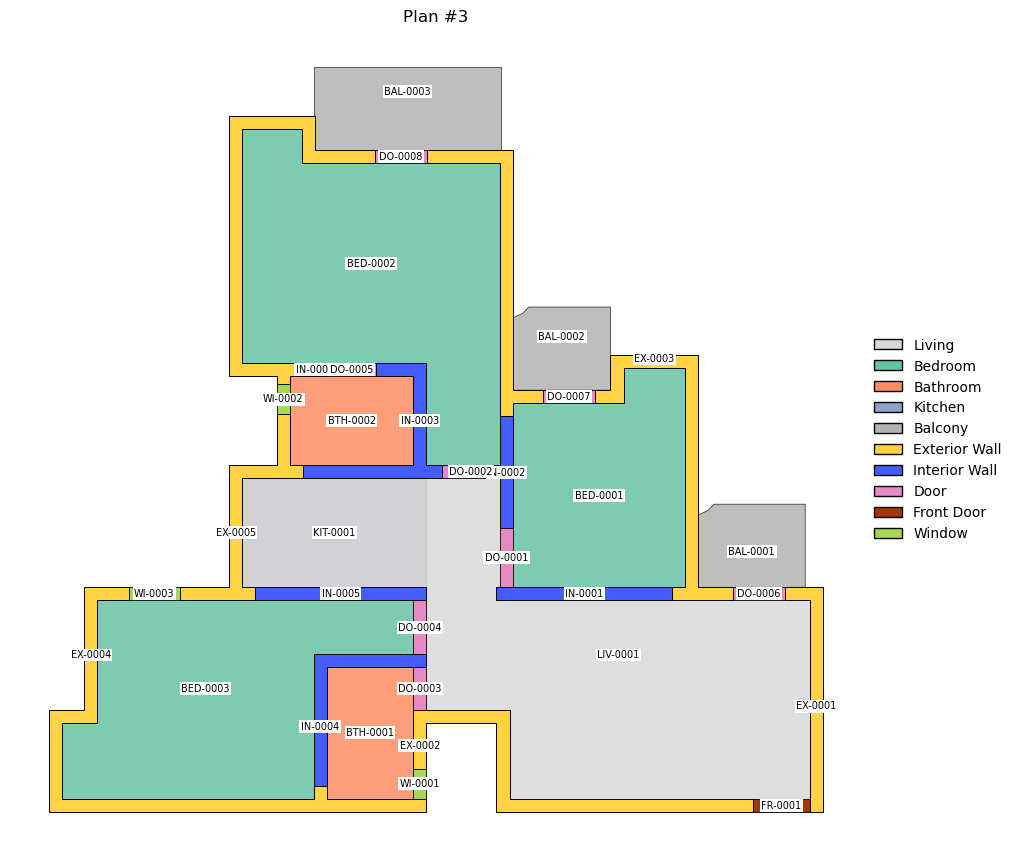

Saved: resplan_plotlabel/plan_00003_ids.png


In [144]:
# 1) make sure an output dir exists
OUT_PLOTLABEL_DIR = "resplan_plotlabel"
os.makedirs(OUT_PLOTLABEL_DIR, exist_ok=True)

# 2) draw from JSON (IDs already relabeled)
ax_or_none = plot_plan_json(json_path, show_ids=True)
fig = ax_or_none.get_figure() if hasattr(ax_or_none, "get_figure") else plt.gcf()

# 4) save and close
out_png = os.path.join(OUT_PLOTLABEL_DIR, f"plan_{idx:05d}_ids.png")
fig.savefig(out_png, dpi=200, bbox_inches="tight")
plt.close(fig)


print("Saved:", out_png)

## Parsing all dataset into JSON (perfect)

In [ ]:
import pickle
import json
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

# Load all plans
with open(DATA_PKL, "rb") as f:
    plans = pickle.load(f)

# Create output directories
OUT_JSON_DIR = "resplan_json"
OUT_PNG_DIR = "resplan_png"
OUT_PLOTLABEL_DIR = "resplan_plotlabel"

os.makedirs(OUT_JSON_DIR, exist_ok=True)
os.makedirs(OUT_PNG_DIR, exist_ok=True)
os.makedirs(OUT_PLOTLABEL_DIR, exist_ok=True)

print(f"Total plans to process: {len(plans)}")

# Process all plans
failed_indices = []

for idx in tqdm(range(len(plans)), desc="Processing plans"):
    try:
        # Normalize and export to JSON
        plan = R.normalize_keys(plans[idx].copy())
        json_path = export_one(idx, plan)
        
        # Move JSON to dedicated directory if needed
        target_json = os.path.join(OUT_JSON_DIR, f"plan_{idx:05d}.json")
        if json_path != target_json:
            os.rename(json_path, target_json)
            json_path = target_json
        
        # Generate unlabeled PNG
        ax = plot_plan_json(json_path, show_ids=False)
        fig = ax.get_figure() if hasattr(ax, "get_figure") else plt.gcf()
        out_png = os.path.join(OUT_PNG_DIR, f"plan_{idx:05d}.png")
        fig.savefig(out_png, dpi=200, bbox_inches="tight")
        plt.close(fig)
        
        # Generate labeled PNG with IDs
        ax = plot_plan_json(json_path, show_ids=True)
        fig = ax.get_figure() if hasattr(ax, "get_figure") else plt.gcf()
        out_labeled = os.path.join(OUT_PLOTLABEL_DIR, f"plan_{idx:05d}_ids.png")
        fig.savefig(out_labeled, dpi=200, bbox_inches="tight")
        plt.close(fig)
        
    except Exception as e:
        failed_indices.append(idx)
        print(f"\nFailed at index {idx}: {e}")
        continue

print(f"\nProcessing complete.")
print(f"Successful: {len(plans) - len(failed_indices)}")
print(f"Failed: {len(failed_indices)}")

if failed_indices:
    print(f"Failed indices: {failed_indices[:20]}...")  # Show first 20
    with open("failed_indices.txt", "w") as f:
        f.write("\n".join(map(str, failed_indices)))